In [151]:
# Import library
import warnings
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from typing import Dict, Tuple

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [152]:
# Read dataset
dat = pd.read_csv("demand_data.csv")

In [153]:
dat.head()
dat.shape

(1273, 23)

In [154]:
# Let's drop the duplicated variable
# This includes month, day_of_week_cat, park_cat, visitors_capped, log1p_visitors

# List of columns to remove
cols_to_drop = [
    "month", 
    "day_of_week_cat", 
    "park_cat", 
    "visitors_capped", 
    "log1p_visitors",
    "month_of_year_cat"
]

# Drop columns only if they currently exist in the dataframe
dat = dat.drop(columns=[c for c in cols_to_drop if c in dat.columns])

# Verify the changes
print(f"Remaining columns: {dat.columns.tolist()}")
dat.head()

Remaining columns: ['visit_date', 'park', 'visitors', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week', 'day_of_year', 'sin_annual', 'cos_annual', 'has_nof_lagoon']


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0


In [155]:
# Define the get metrics function
# Note the benchmark r2 is 0.1424

def get_metrics(y_true, y_pred, model_fit=None):
    """Evaluation suite that handles both OLS and tree-based models."""
    denom = np.sum(np.abs(y_true))
    wmape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan
    
    # Calculate Adj R2 ONLY if a valid model_fit object with the attribute exists
    adj_r2 = np.nan
    if model_fit is not None and hasattr(model_fit, 'rsquared_adj'):
        adj_r2 = model_fit.rsquared_adj
        
    return {
        "wmape": wmape,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "bias": np.mean(y_pred - y_true),
        "adj_r2": adj_r2
    }

In [156]:
# Training random forest for two separate parks

# 2. Setup Feature Groups
cat_features_no_park = ['day_of_week', 'month_of_year']
numeric_features = [
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon'
]

In [157]:
# Add another indicator - how long it is till it is a holiday
# Create a "Days to next holiday" feature
# We assume you have a column 'is_holiday' (1 for holiday, 0 otherwise)

# 3. Feature Engineering for Holidays
dat = dat.sort_values(['park', 'visit_date'])

def get_days_to_holiday(group):
    group_dates = pd.to_datetime(group['visit_date'])
    holiday_dates = pd.to_datetime(group[group['is_holiday'] == 1]['visit_date'])
    if len(holiday_dates) == 0:
        return pd.Series([0] * len(group), index=group.index)
    return group_dates.apply(lambda d: (holiday_dates - d).dt.days.min())

dat['visit_date'] = pd.to_datetime(dat['visit_date'])
dat['is_holiday'] = dat['is_holiday'].astype(int)
dat['days_to_holiday'] = dat.groupby('park', group_keys=False).apply(get_days_to_holiday)
numeric_features.append('days_to_holiday')


dat.head()

,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4


In [158]:
# Create a "Days since salary" feature
# We check the day of the month. If it's 25-30, it's high spend. 
# We can represent this as a proximity feature to the 25th.
dat['day_of_month'] = dat['visit_date'].dt.day
dat['is_payday_window'] = ((dat['day_of_month'] >= 25) | (dat['day_of_month'] <= 3)).astype(int)
numeric_features.append('is_payday_window')

dat.head()
dat.shape

(1273, 20)

In [159]:
# 1. Sort the entire dataset first
dat = dat.sort_values(['park', 'visit_date'])

# 2. Identify where a "streak" changes
# A streak changes if:
# - The holiday status changes (0 to 1 or 1 to 0)
# - OR the park changes (new park = new streak)
change_condition = (dat['is_holiday'] != dat['is_holiday'].shift()) | \
                   (dat['park'] != dat['park'].shift())

# 3. Create a block ID using cumulative sum
dat['holiday_block'] = change_condition.cumsum()

# 4. Calculate the streak within each block
# We group by park AND the block ID to ensure we never cross boundaries
dat['holiday_streak'] = dat.groupby(['park', 'holiday_block'])['is_holiday'].cumsum() * dat['is_holiday']

# 5. Clean up helper columns
dat = dat.drop(columns=['holiday_block'])

# 6. Verify and update features
if 'holiday_streak' not in numeric_features:
    numeric_features.append('holiday_streak')

print("Columns present:", dat.columns.tolist())
dat.head()

Columns present: ['visit_date', 'park', 'visitors', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week', 'day_of_year', 'sin_annual', 'cos_annual', 'has_nof_lagoon', 'days_to_holiday', 'day_of_month', 'is_payday_window', 'holiday_streak']


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday,day_of_month,is_payday_window,holiday_streak
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0,1,1,1
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1,2,1,0
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2,3,1,0
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3,4,0,0
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4,5,0,0


In [160]:
# Create Lag features
dat = dat.sort_values(['park', 'visit_date'])
dat['lag_1'] = dat.groupby('park')['visitors'].shift(1)
dat['lag_7'] = dat.groupby('park')['visitors'].shift(7)

# Create a Rolling Average
dat['rolling_mean_7'] = dat.groupby('park')['visitors'].transform(lambda x: x.rolling(window=7).mean())

# --- INSTEAD OF DROPPING, FILL THE GAPS ---
# Fill the first 7 days of each park with the first available value (or 0)
dat['lag_1'] = dat['lag_1'].fillna(0)
dat['lag_7'] = dat['lag_7'].fillna(0)
dat['rolling_mean_7'] = dat['rolling_mean_7'].fillna(0)

# Optional: You can also use 'bfill' (backfill) to use the first real value found later
# dat = dat.fillna(method='bfill')
numeric_features.append('lag_1')
numeric_features.append('lag_7')
numeric_features.append('rolling_mean_7')

In [161]:
# 1. Update feature to use
features_to_use = cat_features_no_park + numeric_features

# 2. Re-define the Preprocessor (without 'park')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
    ],
    remainder='passthrough'
)

# 4. Prepare Variables for Loop
features_to_use = cat_features_no_park + numeric_features
target = 'visitors' # Defined target variable
months = sorted(dat["visit_date"].dt.to_period("M").unique())
parks = dat['park'].unique()

# 5. Define Preprocessor (Once, outside the loop)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
    ],
    remainder='passthrough'
)

# 6. Training Loop
results = []
final_importances = {}

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    
    # Global time split
    train_df_full = dat[dat["visit_date"] <= train_end]
    test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p]
        test_df = test_df_full[test_df_full['park'] == p]
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define and Fit Model (Using raw target)
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42))
        ])
        
        # Train on raw visitors
        model.fit(train_df[features_to_use], train_df[target])

        # 2. Inside your loop, update the storage after model.fit()
        # (Place this logic exactly after your model.fit line)

        model.fit(train_df[features_to_use], train_df[target])
    
        # --- ADD THIS: Capture importances ---
        feature_names = model.named_steps['preprocessor'].get_feature_names_out()
        importances = model.named_steps['regressor'].feature_importances_
    
        # Store in dictionary (this overwrites with the most recent month's model)
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        # -------------------------------------
        
        # Predict (Directly, no np.expm1 since we aren't using logs)
        pred = np.clip(model.predict(test_df[features_to_use]), 0, None)
        
        # Evaluate
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        metrics["test_month"] = months[i+1]
        results.append(metrics)

# 7. View Results
results_df = pd.DataFrame(results)
print("\n=== Final Performance by Park ===")
summary = results_df.groupby("park").mean(numeric_only=True).round(4)
print(summary)


=== Final Performance by Park ===
                wmape       mae       rmse      r2      bias  adj_r2
park                                                                
Lost World     0.3301  597.4967   816.9140  0.3010  181.1149     NaN
Sunway Lagoon  0.3650  955.2047  1330.0355  0.1145  228.7324     NaN


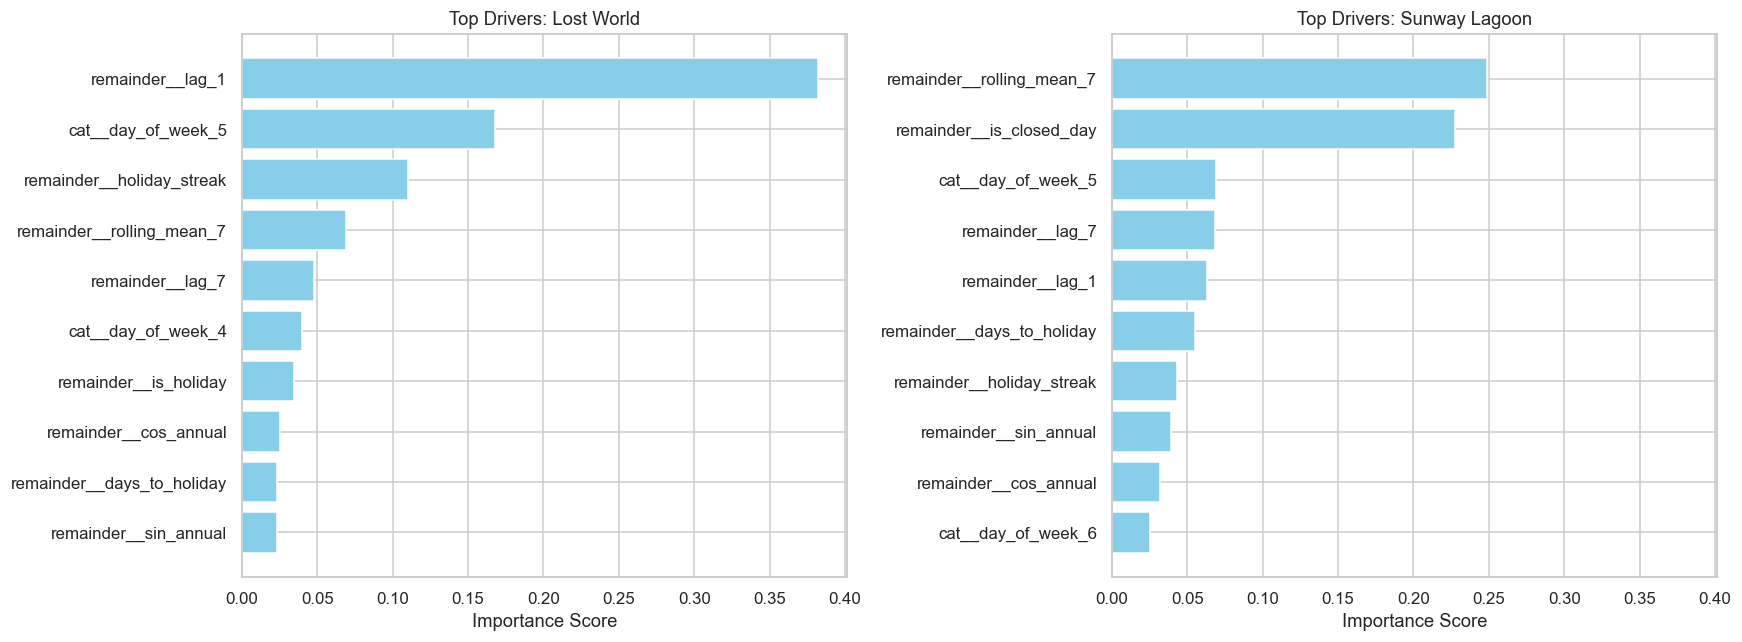

In [162]:
# 3. Plotting Code (Run this AFTER your loop finishes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
axes = axes.flatten()

for idx, p in enumerate(parks):
    if p in final_importances:
        df = final_importances[p].head(10) # Top 10 features
        axes[idx].barh(df['Feature'], df['Importance'], color='skyblue')
        axes[idx].set_title(f"Top Drivers: {p}")
        axes[idx].invert_yaxis()
        axes[idx].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

Problem: Random Forest always take average, miss the extreme values.
Performance of WMAPE worse than the OLS.

In [163]:
# Try XGBOOST

# 1. Ensure XGBoost is imported
from xgboost import XGBRegressor

# 2. Re-define the Preprocessor (Ensure this is run once before the loop)
# (Assuming cat_features_no_park is already defined)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_no_park)
    ],
    remainder='passthrough'
)

# 3. Training Loop with Park Split
results = []
final_importances = {}

# Ensure months and parks are defined
months = sorted(dat["visit_date"].dt.to_period("M").unique())
parks = dat['park'].unique()

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    
    # Global time split
    train_df_full = dat[dat["visit_date"] <= train_end]
    test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p]
        test_df = test_df_full[test_df_full['park'] == p]
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define Pipeline with XGBRegressor
        # We increase n_estimators and lower learning_rate for better "peak" capturing
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', XGBRegressor(
                n_estimators=500, 
                learning_rate=0.05, 
                max_depth=6, 
                subsample=0.8,
                random_state=42
            ))
        ])
        
        # Fit once
        model.fit(train_df[features_to_use], train_df[target])
    
        # --- Capture importances ---
        feature_names = model.named_steps['preprocessor'].get_feature_names_out()
        importances = model.named_steps['regressor'].feature_importances_
    
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict 
        pred = np.clip(model.predict(test_df[features_to_use]), 0, None)
        
        # Evaluate
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        metrics["test_month"] = months[i+1]
        results.append(metrics)

# 4. View Results per Park
results_df = pd.DataFrame(results)
print("\n=== Final Performance by Park (XGBoost) ===")
summary = results_df.groupby("park").mean(numeric_only=True).round(4)
print(summary)



=== Final Performance by Park (XGBoost) ===
                wmape       mae       rmse      r2      bias  adj_r2
park                                                                
Lost World     0.3621  658.3979   861.4937  0.2343  205.9420     NaN
Sunway Lagoon  0.3662  961.7790  1366.3554 -0.0105  199.3182     NaN


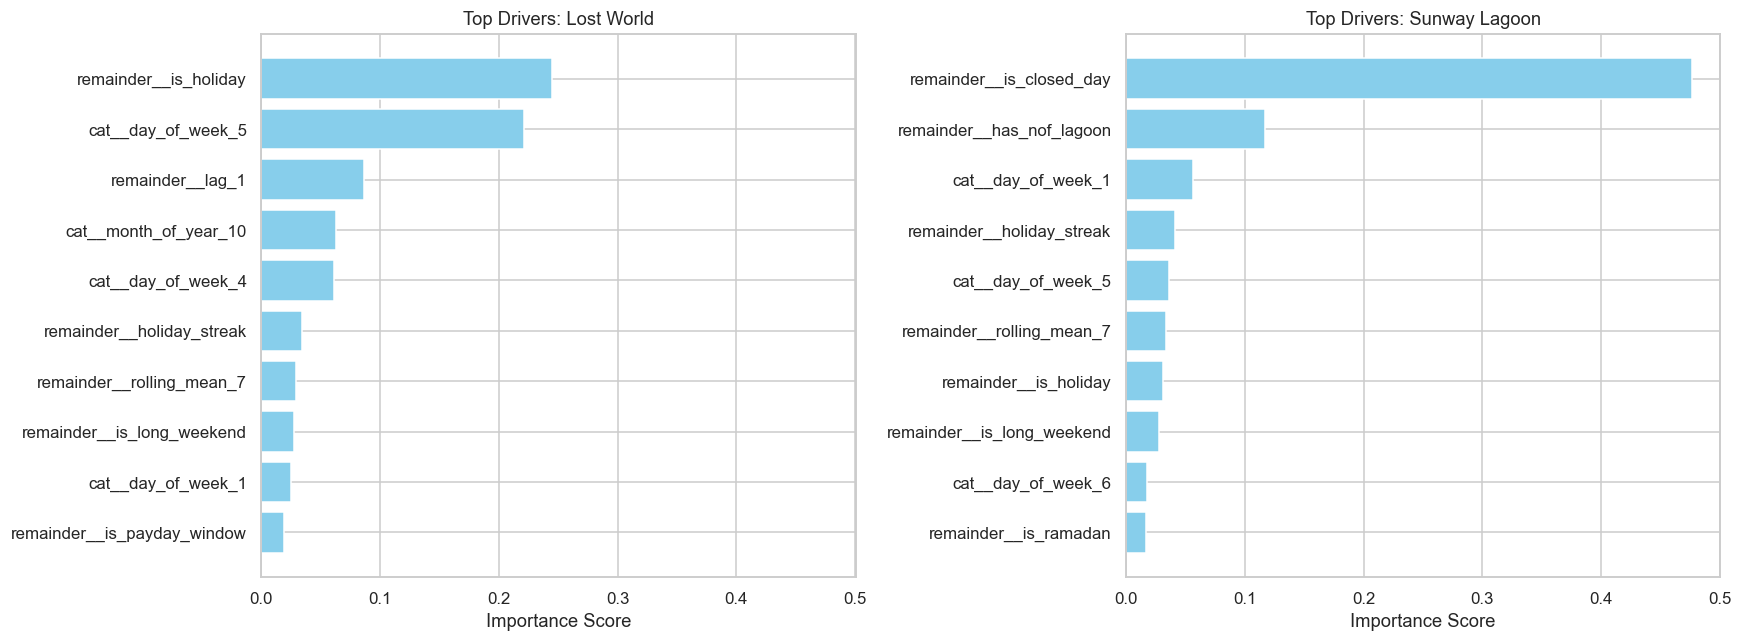

In [164]:
# 3. Plotting Code (Run this AFTER your loop finishes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
axes = axes.flatten()

for idx, p in enumerate(parks):
    if p in final_importances:
        df = final_importances[p].head(10) # Top 10 features
        axes[idx].barh(df['Feature'], df['Importance'], color='skyblue')
        axes[idx].set_title(f"Top Drivers: {p}")
        axes[idx].invert_yaxis()
        axes[idx].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()